# **Crime Data Analysis Project**

### **Introduction**

In an ever-evolving world, analyzing crime data is crucial for understanding public safety dynamics. This project presents a comprehensive analysis of real-world crime data from 2020 to the present, uncovering patterns, trends, and factors contributing to crime rates. This analysis benefits law enforcement, policymakers, community leaders, and citizens by providing insights that inform crime prevention strategies, resource allocation, and safer community promotion. You can download the dataset used in this project from Crime Data from 2020 to Present.

### **Importing Libraries**

In [ ]:
import pandas as pd
import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Crime_Data_from_2020_to_Present.csv')
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [ ]:
print(df.dtypes)
print(df.columns)

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object
Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc',

### **Data Cleaning**

This dataset, representing crimes in Los Angeles from 2020 to October 2023, requires extensive cleaning. We address missing values, standardize time formats, consolidate crime codes, and create meaningful addresses. We also fill gaps in the victim age, premise code, and premise description columns with appropriate values. The cleaned data allows for thorough analysis and visualization of crime trends.



In [ ]:
missing_values = [0,'0','','-']
df = pd.read_csv('Crime_Data_from_2020_to_Present.csv', na_values = missing_values)
# df.drop_duplicates() # This doesn't modify the dataframe in place, consider assigning the result back if needed
df['TIME OCC'] = (pd.to_datetime(df['TIME OCC']
                                             .fillna(0).astype(int).astype(str)
                                             .str.zfill(4), format='%H%M', errors='coerce')
                              .dt.strftime('%H:%M')
                              .fillna('00:00'))

df['Mocodes'] = df['Mocodes'].astype(str).apply(lambda x : x.split())
# Use np.nan instead of np.NaN as suggested by the traceback
df['Vict Age'] = df['Vict Age'].apply(lambda x : np.nan if x<0 else x)
df['Crm Cds'] = df[['Crm Cd 1','Crm Cd 2','Crm Cd 3','Crm Cd 4']].values.tolist()
del df['Crm Cd 1']
del df['Crm Cd 2']
del df['Crm Cd 3']
del df['Crm Cd 4']
df['location'] = df[['LOCATION','Cross Street']].apply(lambda x : ', '.join(x[x.notnull()]), axis = 1)
del df['LOCATION']
del df['Cross Street']

# When using apply with groupby and fillna/mode, it's better to use transform to ensure the result
# aligns with the original index. Also, mode() can return multiple values; choosing the first one is common.
df['Vict Age'] = df.groupby('Crm Cd')['Vict Age'].transform(lambda x : x.fillna(x.median()))
df['Premis Cd'] = df.groupby('Crm Cd')['Premis Cd'].transform(lambda x : x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
df['Premis Desc'] = df.groupby('Crm Cd')['Premis Desc'].transform(lambda x : x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))

df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

/tmp/ipython-input-4-4012694097.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
/tmp/ipython-input-4-4012694097.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


In [ ]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,LAT,LON,Crm Cds,location
0,211507896,2021-04-11,2020-11-07,08:45,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,34.2124,-118.4092,"[354.0, nan, nan, nan]",7800 BEEMAN AV
1,201516622,2020-10-21,2020-10-18,18:45,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,34.1993,-118.4203,"[230.0, nan, nan, nan]","ATOLL AV, N GAULT"
2,240913563,2024-12-10,2020-10-30,12:40,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,34.1847,-118.4509,"[354.0, nan, nan, nan]",14600 SYLVAN ST
3,210704711,2020-12-24,2020-12-24,13:10,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,101.0,STREET,NaN,NaN,IC,Invest Cont,34.0339,-118.3747,"[331.0, nan, nan, nan]",6000 COMEY AV
4,201418201,2020-10-03,2020-09-29,18:30,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,103.0,ALLEY,NaN,NaN,IC,Invest Cont,33.9813,-118.4350,"[420.0, nan, nan, nan]",4700 LA VILLA MARINA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005062 entries, 0 to 1005061
Data columns (total 24 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   DR_NO           1005062 non-null  int64         
 1   Date Rptd       1005062 non-null  datetime64[ns]
 2   DATE OCC        1005062 non-null  datetime64[ns]
 3   TIME OCC        1005062 non-null  object        
 4   AREA            1005062 non-null  int64         
 5   AREA NAME       1005062 non-null  object        
 6   Rpt Dist No     1005062 non-null  int64         
 7   Part 1-2        1005062 non-null  int64         
 8   Crm Cd          1005062 non-null  int64         
 9   Crm Cd Desc     1005062 non-null  object        
 10  Mocodes         1005062 non-null  object        
 11  Vict Age        1004906 non-null  float64       
 12  Vict Sex        860344 non-null   object        
 13  Vict Descent    860331 non-null   object        
 14  Premis Cd       10

In [ ]:
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


In [ ]:
df = df.loc[~((df['Vict Age'].isnull())+(df['Premis Cd'].isnull())+(df['Premis Desc'].isnull()))]

/tmp/ipython-input-8-3228366473.py:1: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  df = df.loc[~((df['Vict Age'].isnull())+(df['Premis Cd'].isnull())+(df['Premis Desc'].isnull()))]


In [ ]:
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


**Extracting year, month, day and weekday from 'DATE OCC' column**

In [ ]:
df['year']=df['DATE OCC'].dt.year
df['month']=df['DATE OCC'].dt.strftime('%b')
df['month_num'] = df['DATE OCC'].dt.month
df['day']=df['DATE OCC'].dt.day
df['weekday']=df['DATE OCC'].dt.strftime('%A')
df['weekday_num'] = df['DATE OCC'].dt.strftime('%w')

In [ ]:
df[['DATE OCC','year','month','month_num','day','weekday','weekday_num']].head()

,DATE OCC,year,month,month_num,day,weekday,weekday_num
0,2020-11-07,2020,Nov,11,7,Saturday,6
1,2020-10-18,2020,Oct,10,18,Sunday,0
2,2020-10-30,2020,Oct,10,30,Friday,5
3,2020-12-24,2020,Dec,12,24,Thursday,4
4,2020-09-29,2020,Sep,9,29,Tuesday,2


**Crime distribution across year**

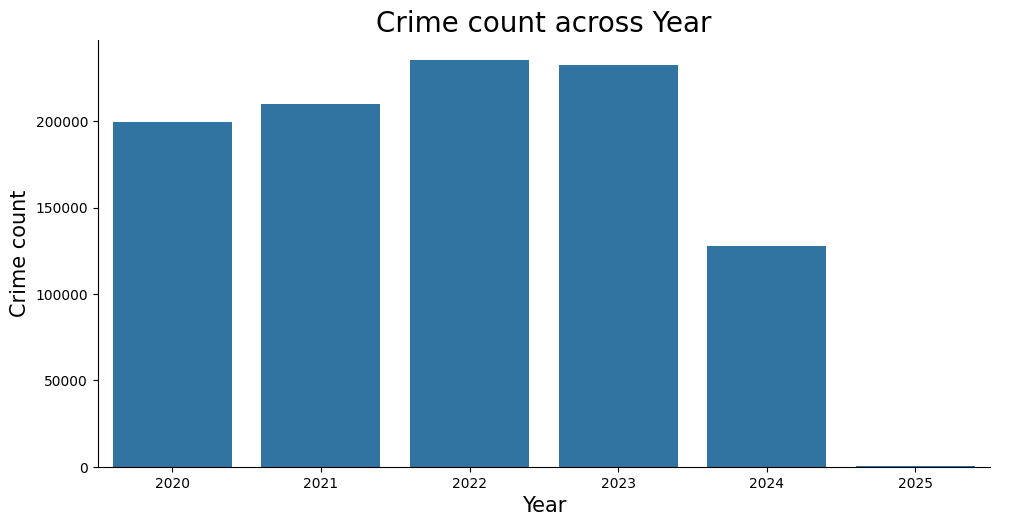

In [ ]:
sns.catplot(x = "year",
            data = df,
            aspect = 2.0,
            kind = "count")
plt.title('Crime count across Year', fontsize = 20)
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Crime count', fontsize = 15)
plt.show()

**Average monthly Crime Rate across years**

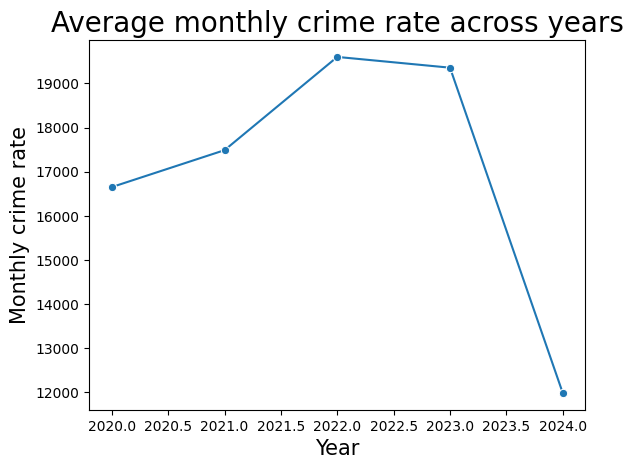

In [15]:
df_year = df.loc[df['DATE OCC'] < '2024-10-01'].groupby(['year','month_num'])['DR_NO'].count()
df_year = df_year.reset_index().rename(columns = {'DR_NO' : 'crime_count'})
df_year_grouped = df_year.groupby('year')['crime_count'].mean()
df_year_grouped = df_year_grouped.reset_index()
df_year_grouped['crime_count'] = df_year_grouped['crime_count'].round()

sns.lineplot(x = 'year', y = 'crime_count', data = df_year_grouped, marker = 'o')
plt.title('Average monthly crime rate across years', fontsize = 20)
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Monthly crime rate', fontsize = 15)
plt.show()

**Crime distribution across months**

/tmp/ipython-input-17-349526360.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Month")


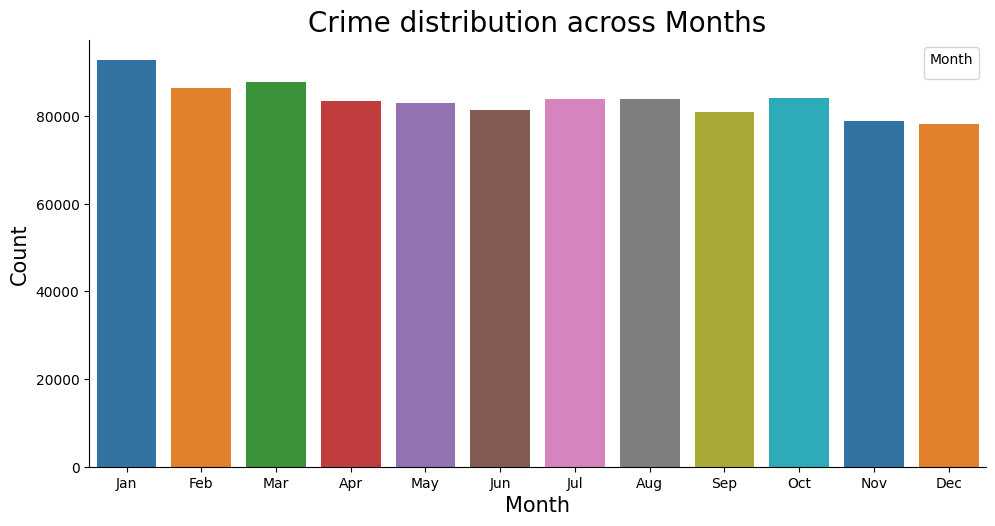

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(x="month",
            data=df.sort_values(by='month_num'),
            kind="count",
            aspect=2.0,
            hue="month",
            palette="tab10")

plt.title('Crime distribution across Months', fontsize=20)
plt.xlabel('Month', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.legend(title="Month")
plt.show()

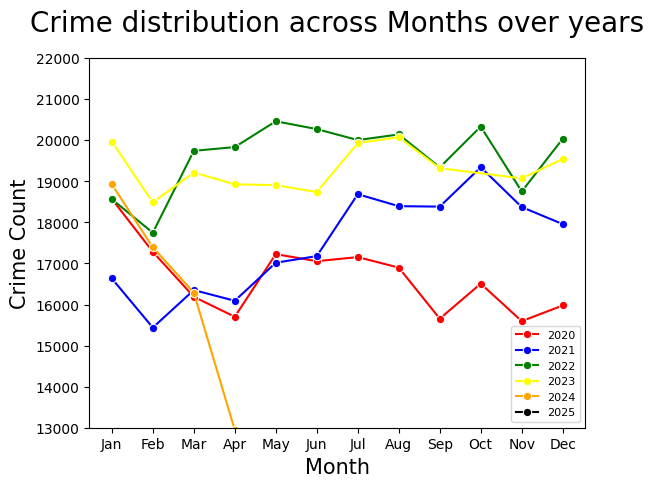

In [21]:
df_group = df.groupby(['year','month','month_num'])['DR_NO'].count()
df_group = df_group.reset_index().rename(columns = {'DR_NO' : 'crime_count'})
df_group = df_group.loc[~((df_group.year == 2023)&(df_group.month_num == 10))]

ax = sns.lineplot(x = 'month', y = 'crime_count', data = df_group.loc[df_group.year == 2020].sort_values(by = 'month_num'), color = 'red', marker = 'o', label = '2020')
ax = sns.lineplot(x = 'month', y = 'crime_count', data = df_group.loc[df_group.year == 2021].sort_values(by = 'month_num'), color = 'blue', marker = 'o', label = '2021')
ax = sns.lineplot(x = 'month', y = 'crime_count', data = df_group.loc[df_group.year == 2022].sort_values(by = 'month_num'), color = 'green', marker = 'o', label = '2022')
ax = sns.lineplot(x = 'month', y = 'crime_count', data = df_group.loc[df_group.year == 2023].sort_values(by = 'month_num'), color = 'yellow', marker = 'o', label = '2023')
ax = sns.lineplot(x = 'month', y = 'crime_count', data = df_group.loc[df_group.year == 2024].sort_values(by = 'month_num'), color = 'orange', marker = 'o', label = '2024')
ax = sns.lineplot(x = 'month', y = 'crime_count', data = df_group.loc[df_group.year == 2025].sort_values(by = 'month_num'), color = 'black', marker = 'o', label = '2025')

ax.set_ylim(13000,22000)
plt.legend(fontsize = 8, loc = 'lower right')
plt.title('Crime distribution across Months over years', fontsize = 20, y=1.05)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Crime Count', fontsize = 15)
plt.show()

/tmp/ipython-input-20-2786593112.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation = 90, fontsize = 8)


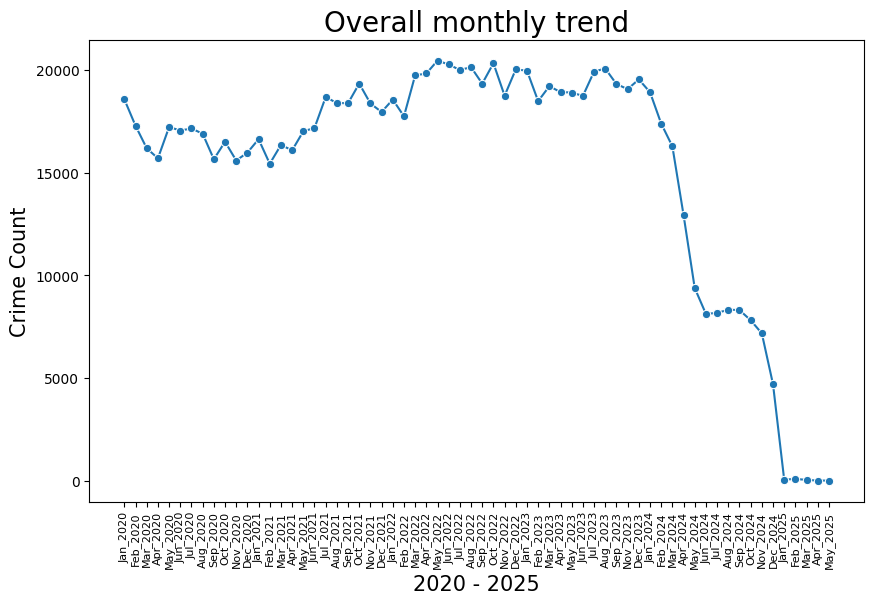

In [20]:
df_group['month_year'] = df_group['month'].astype(str) +'_'+ df_group['year'].astype(str)
plt.figure(figsize = (10,6))
plot = sns.lineplot(x = 'month_year', y = 'crime_count', data = df_group.sort_values(by = ['year','month_num']), marker = 'o')
plt.xlabel('2020 - 2025', fontsize = 15)
plt.ylabel('Crime Count', fontsize = 15)
plt.title('Overall monthly trend', fontsize = 20)
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90, fontsize = 8)
plt.show()

### **Effects of Major events or Economic factors**

**Major earthquakes in LA since 2020**

/tmp/ipython-input-23-1957337738.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot1.set_xticklabels(plot1.get_xticklabels(), rotation = 30, fontsize = 6)
/tmp/ipython-input-23-1957337738.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot2.set_xticklabels(plot2.get_xticklabels(), rotation = 30, fontsize = 6)
/tmp/ipython-input-23-1957337738.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot3.set_xticklabels(plot3.get_xticklabels(), rotation = 30, fontsize = 6)
/tmp/ipython-input-23-1957337738.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot4.set_xticklabels(plot4.get_xticklabels(), rotation = 30, fontsize = 6)


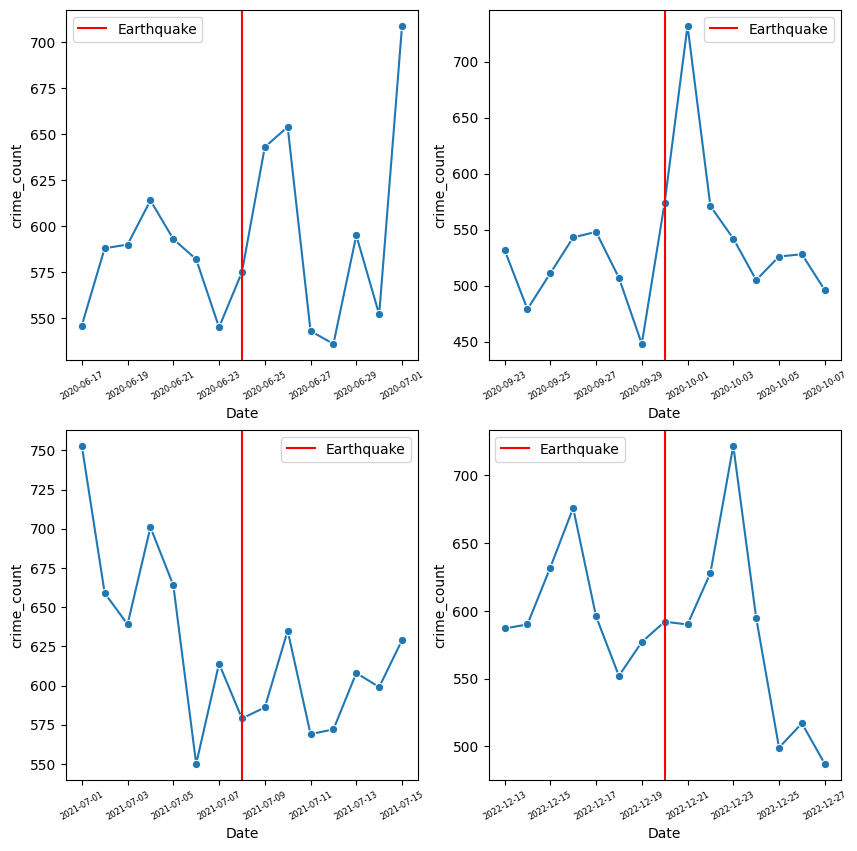

In [23]:
date_e2 = '2020-06-24'
date_e2_s = '2020-06-17'
date_e2_f = '2020-07-01'

df_e2 = df.loc[(df['DATE OCC'] >= date_e2_s)&(df['DATE OCC'] <= date_e2_f)]['DATE OCC'].value_counts()
df_e2 = df_e2.reset_index().rename(columns = {'index' : 'Date', 'DATE OCC' : 'crime_count'})

date_e3 = '2020-09-30'
date_e3_s = '2020-09-23'
date_e3_f = '2020-10-07'

df_e3 = df.loc[(df['DATE OCC'] >= date_e3_s)&(df['DATE OCC'] <= date_e3_f)]['DATE OCC'].value_counts()
df_e3 = df_e3.reset_index().rename(columns = {'index' : 'Date', 'DATE OCC' : 'crime_count'})

date_e4 = '2021-07-08'
date_e4_s = '2021-07-01'
date_e4_f = '2021-07-15'

df_e4 = df.loc[(df['DATE OCC'] >= date_e4_s)&(df['DATE OCC'] <= date_e4_f)]['DATE OCC'].value_counts()
df_e4 = df_e4.reset_index().rename(columns = {'index' : 'Date', 'DATE OCC' : 'crime_count'})

date_e5 = '2022-12-20'
date_e5_s = '2022-12-13'
date_e5_f = '2022-12-27'

df_e5 = df.loc[(df['DATE OCC'] >= date_e5_s)&(df['DATE OCC'] <= date_e5_f)]['DATE OCC'].value_counts()
df_e5 = df_e5.reset_index().rename(columns = {'index' : 'Date', 'DATE OCC' : 'crime_count'})

fig, axes = plt.subplots(2,2, figsize = (10,10))

plot1 = sns.lineplot(x = 'crime_count', y = 'count', data = df_e2, marker = 'o', ax = axes[0][0])
plot1.set_xticklabels(plot1.get_xticklabels(), rotation = 30, fontsize = 6)
plot1.set(xlabel="Date", ylabel="crime_count")
plot1.axvline(x = datetime.date(2020,6,24), color = 'red', label = 'Earthquake')
plot1.legend()
plot2 = sns.lineplot(x = 'crime_count', y = 'count', data = df_e3, marker = 'o', ax = axes[0][1])
plot2.set_xticklabels(plot2.get_xticklabels(), rotation = 30, fontsize = 6)
plot2.set(xlabel="Date", ylabel="crime_count")
plot2.axvline(x = datetime.date(2020,9,30), color = 'red', label = 'Earthquake')
plot2.legend()
plot3 = sns.lineplot(x = 'crime_count', y = 'count', data = df_e4, marker = 'o', ax = axes[1][0])
plot3.set_xticklabels(plot3.get_xticklabels(), rotation = 30, fontsize = 6)
plot3.set(xlabel="Date", ylabel="crime_count")
plot3.axvline(x = datetime.date(2021,7,8), color = 'red', label = 'Earthquake')
plot3.legend()
plot4 = sns.lineplot(x = 'crime_count', y = 'count', data = df_e5, marker = 'o', ax = axes[1][1])
plot4.set_xticklabels(plot4.get_xticklabels(), rotation = 30, fontsize = 6)
plot4.set(xlabel="Date", ylabel="crime_count")
plot4.axvline(x = datetime.date(2022,12,20), color = 'red', label = 'Earthquake')
plot4.legend()
plt.show()

In [24]:
df_e2.columns

Index(['crime_count', 'count'], dtype='object')

**Recession**

/tmp/ipython-input-28-1623982158.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation = 45, fontsize = 8)


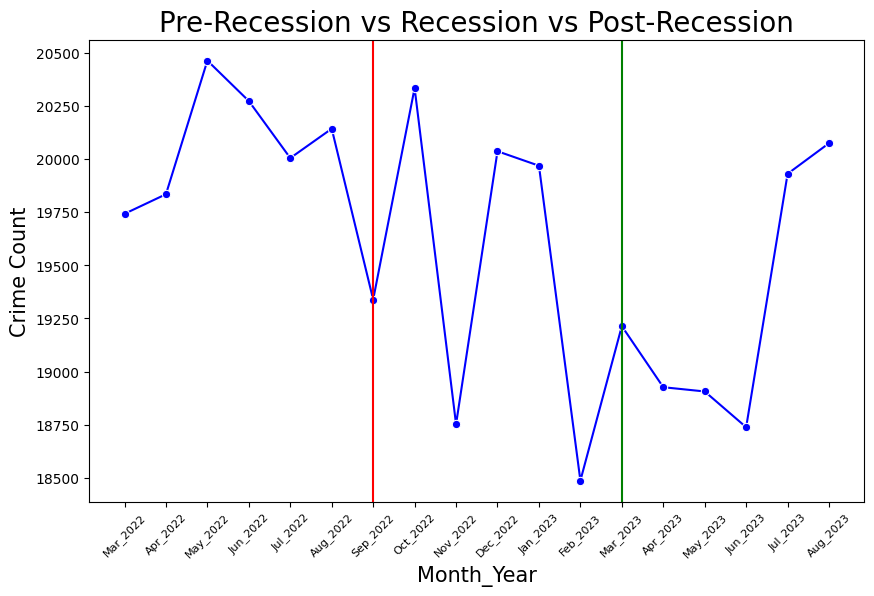

In [28]:
date_pre_rec = '2022-03-01'
date_rec_1 = '2022-09-01'
date_rec_2 = '2023-03-01'
date_post_rec = '2023-08-31'

df_rec = df.loc[(df['DATE OCC'] >= date_pre_rec)&(df['DATE OCC'] <= date_post_rec)]
df_rec = df_rec.groupby(['year','month','month_num'])['DR_NO'].count()
df_rec = df_rec.reset_index().rename(columns = {'DR_NO' : 'crime_count'})
df_rec['month_year'] = df_rec['month'].astype(str) +'_'+ df_rec['year'].astype(str)

plt.figure(figsize = (10,6))
plot = sns.lineplot(x = 'month_year', y = 'crime_count', data = df_rec.sort_values(by = ['year','month_num']), marker = 'o', color = 'blue')
plt.xlabel('Month_Year', fontsize = 15)
plt.ylabel('Crime Count', fontsize = 15)
plt.title('Pre-Recession vs Recession vs Post-Recession', fontsize = 20)
plot.set_xticklabels(plot.get_xticklabels(), rotation = 45, fontsize = 8)
plot.axvline(x = 'Sep_2022', color = 'red', label = 'Recession Start')
plot.axvline(x = 'Mar_2023', color = 'green', label = 'Recession End')

plt.show()

**Covid-19**

/tmp/ipython-input-29-2529910305.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation = 90, fontsize = 8)


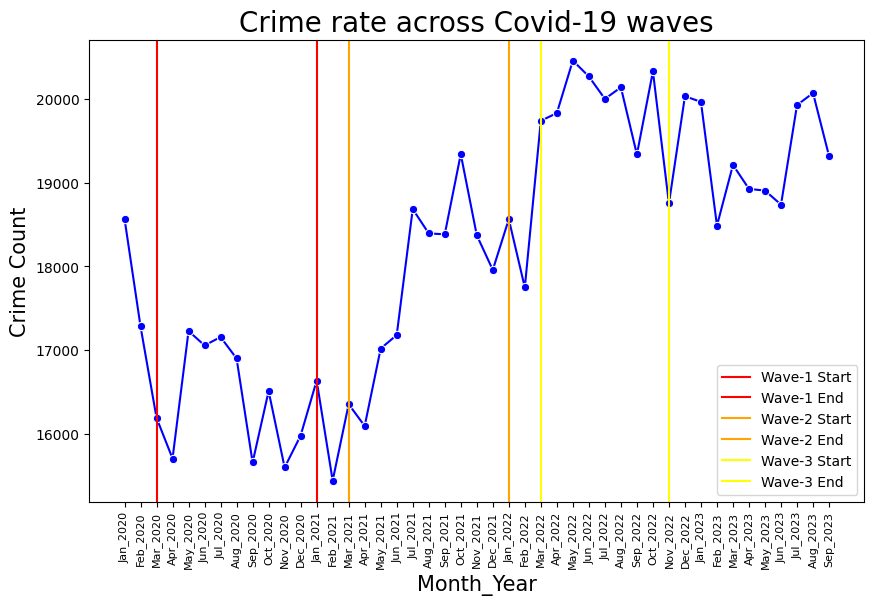

In [29]:
date_w1_start = '2020-03-01'
date_w1_end = '2021-01-31'
date_w2_start = '2021-03-01'
date_w2_end = '2022-01-31'
date_w3_start = '2022-03-01'
date_w3_end = '2022-10-31'

df_cov = df.loc[df['DATE OCC'] < '2023-10-01']
df_cov = df_cov.groupby(['year','month','month_num'])['DR_NO'].count()
df_cov = df_cov.reset_index().rename(columns = {'DR_NO' : 'crime_count'})
df_cov['month_year'] = df_cov['month'].astype(str) +'_'+ df_cov['year'].astype(str)

plt.figure(figsize = (10,6))
plot = sns.lineplot(x = 'month_year', y = 'crime_count', data = df_cov.sort_values(by = ['year','month_num']), marker = 'o', color = 'blue')
plt.xlabel('Month_Year', fontsize = 15)
plt.ylabel('Crime Count', fontsize = 15)
plt.title('Crime rate across Covid-19 waves', fontsize = 20)
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90, fontsize = 8)
plot.axvline(x = 'Mar_2020', color = 'red', label = 'Wave-1 Start')
plot.axvline(x = 'Jan_2021', color = 'red', label = 'Wave-1 End')
plot.axvline(x = 'Mar_2021', color = 'orange', label = 'Wave-2 Start')
plot.axvline(x = 'Jan_2022', color = 'orange', label = 'Wave-2 End')
plot.axvline(x = 'Mar_2022', color = 'yellow', label = 'Wave-3 Start')
plot.axvline(x = 'Nov_2022', color = 'yellow', label = 'Wave-3 End')

plt.legend()
plt.show()

**Crime distribution across weekdays**

weekday
Friday       153663
Saturday     147442
Wednesday    142707
Thursday     141805
Monday       141531
Sunday       139634
Tuesday      138124
Name: count, dtype: int64


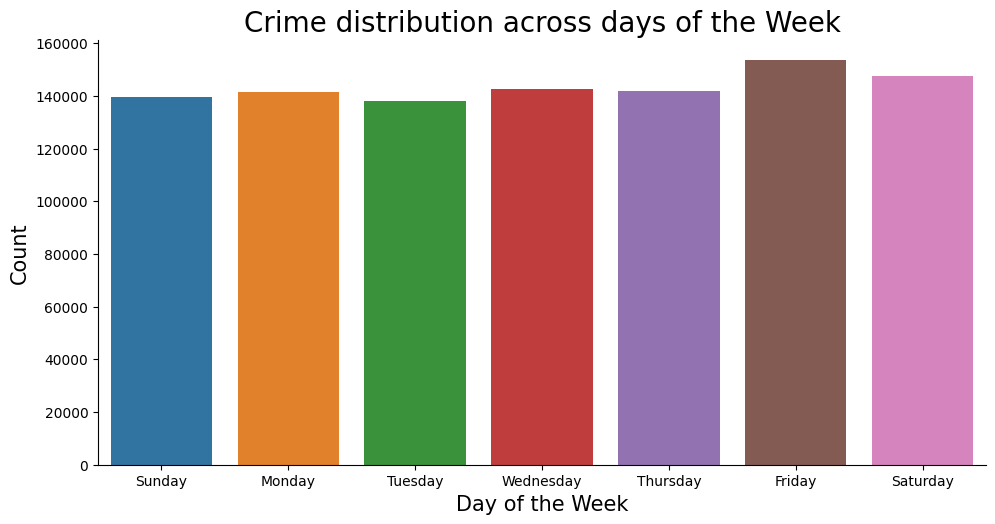

In [32]:
print(df['weekday'].value_counts())
sns.catplot(x = "weekday",
            data = df.sort_values(by = 'weekday_num'),
            aspect = 2.0,
            kind = "count",
            hue='weekday')
plt.title('Crime distribution across days of the Week', fontsize = 20)
plt.xlabel('Day of the Week', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.show()

**Crime distribution across different timeframes in a day**

In [33]:
def time_bin(x) :
    if x.time() < datetime.time(2) :
        return '00:00-02:00'
    elif x.time() < datetime.time(4) :
        return '02:00-04:00'
    elif x.time() < datetime.time(6) :
        return '04:00-06:00'
    elif x.time() < datetime.time(8) :
        return '06:00-08:00'
    elif x.time() < datetime.time(10) :
        return '08:00-10:00'
    elif x.time() < datetime.time(12) :
        return '10:00-12:00'
    elif x.time() < datetime.time(14) :
        return '12:00-14:00'
    elif x.time() < datetime.time(16) :
        return '14:00-16:00'
    elif x.time() < datetime.time(18) :
        return '16:00-18:00'
    elif x.time() < datetime.time(20) :
        return '18:00-20:00'
    elif x.time() < datetime.time(22) :
        return '20:00-22:00'
    else :
        return '22:00-00:00'

In [34]:
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'])
df['time_bin'] = df['TIME OCC'].apply(time_bin)
df['TIME OCC'] = df['TIME OCC'].dt.strftime('%H:%M')
df[['TIME OCC','time_bin']]

/tmp/ipython-input-34-2268286581.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TIME OCC'] = pd.to_datetime(df['TIME OCC'])


,TIME OCC,time_bin
0,08:45,08:00-10:00
1,18:45,18:00-20:00
2,12:40,12:00-14:00
3,13:10,12:00-14:00
4,18:30,18:00-20:00
...,...,...
1005057,22:00,22:00-00:00
1005058,12:00,12:00-14:00
1005059,12:00,12:00-14:00
1005060,19:00,18:00-20:00


time_bin
18:00-20:00    115552
12:00-14:00    113391
16:00-18:00    111788
20:00-22:00    107134
14:00-16:00    102119
22:00-00:00     91369
10:00-12:00     86683
08:00-10:00     73759
00:00-02:00     70217
06:00-08:00     49451
02:00-04:00     47396
04:00-06:00     36047
Name: count, dtype: int64


/tmp/ipython-input-36-4142008742.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  weekday_plot.set_xticklabels(weekday_plot.get_xticklabels(), rotation = 45, fontsize = 8)


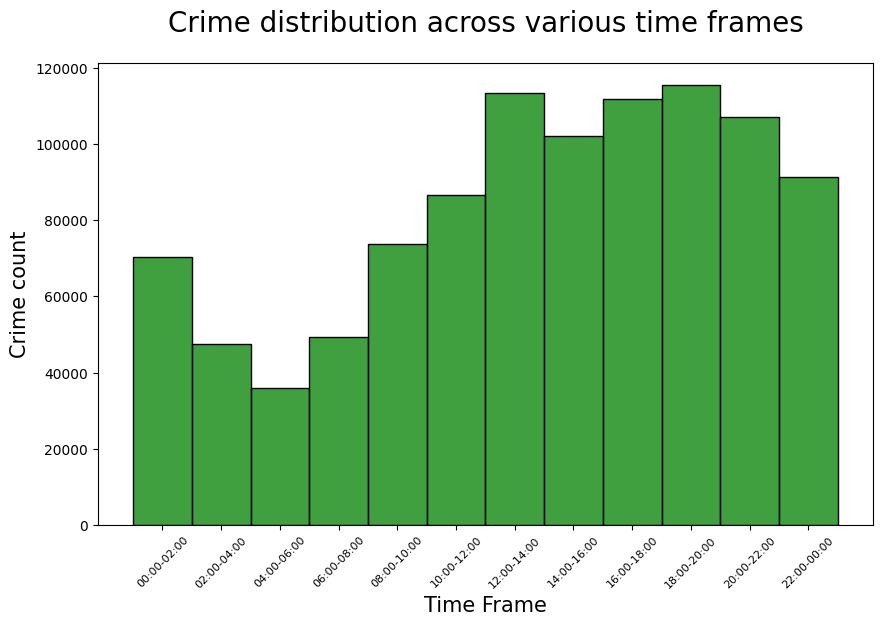

In [36]:
print(df['time_bin'].value_counts())
plt.figure(figsize = (10,6))
weekday_plot = sns.histplot(x = 'time_bin', data = df.sort_values(by = 'TIME OCC'), color = 'green')
weekday_plot.set_xticklabels(weekday_plot.get_xticklabels(), rotation = 45, fontsize = 8)
plt.title('Crime distribution across various time frames', fontsize = 20, y=1.05)
plt.xlabel('Time Frame', fontsize = 15)
plt.ylabel('Crime count', fontsize = 15)
plt.show()

**Top 10 Crime types**

/tmp/ipython-input-39-3098624730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  crime_plot = sns.barplot(x = 'crime_count', y = 'count', data = df_crime_types[:10],palette='tab10')
/tmp/ipython-input-39-3098624730.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  crime_plot.set_xticklabels(crime_plot.get_xticklabels(), rotation = 90, fontsize = 8)


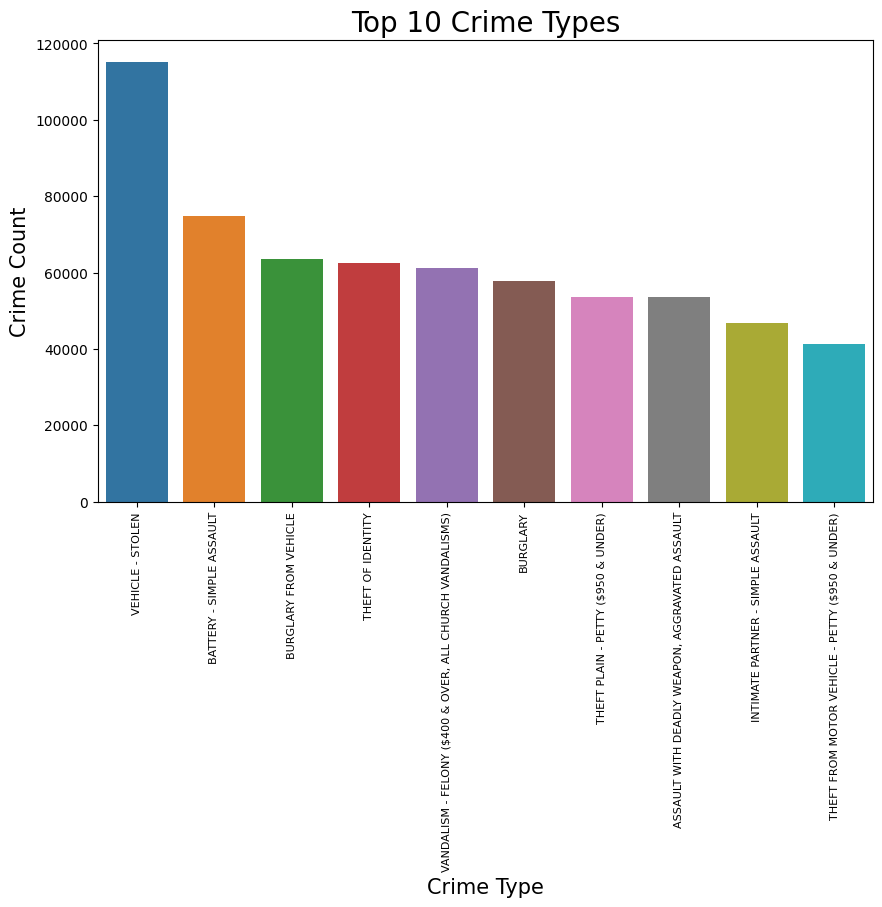

In [39]:
df_crime_types = df['Crm Cd Desc'].value_counts()
df_crime_types = df_crime_types.reset_index().rename(columns = {'Crm Cd Desc' : 'crime_count', 'index' : 'crime_type'})

plt.figure(figsize = (10,6))
crime_plot = sns.barplot(x = 'crime_count', y = 'count', data = df_crime_types[:10],palette='tab10')
crime_plot.set_xticklabels(crime_plot.get_xticklabels(), rotation = 90, fontsize = 8)
plt.title('Top 10 Crime Types', fontsize = 20)
plt.xlabel('Crime Type', fontsize = 15)
plt.ylabel('Crime Count', fontsize = 15)
plt.show()

In [40]:
df_crime_types

,crime_count,count
0,VEHICLE - STOLEN,115226
1,BATTERY - SIMPLE ASSAULT,74839
2,BURGLARY FROM VEHICLE,63517
3,THEFT OF IDENTITY,62539
4,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",61092
...,...,...
133,FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS ...,5
134,FIREARMS RESTRAINING ORDER (FIREARMS RO),4
135,DISHONEST EMPLOYEE ATTEMPTED THEFT,4
136,TRAIN WRECKING,1


**Grouping the crime types**

In [43]:
crime_groups = pd.read_csv('Crime_Groups.csv')
crime_groups.head()

,Crm Cd Desc,Group
0,BATTERY - SIMPLE ASSAULT,Assault
1,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,Sexual Offence
2,VANDALISM - MISDEAMEANOR ($399 OR UNDER),Vandalism
3,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Vandalism
4,"RAPE, FORCIBLE",Sexual Offence


In [44]:
crime_groups.describe()

,Crm Cd Desc,Group
count,138,138
unique,138,13
top,BATTERY - SIMPLE ASSAULT,Other
freq,1,37


In [45]:
df = df.merge(crime_groups, on = 'Crm Cd Desc')
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cds,location,year,month,month_num,day,weekday,weekday_num,time_bin,Group
0,211507896,2021-04-11,2020-11-07,08:45,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,"[354.0, nan, nan, nan]",7800 BEEMAN AV,2020,Nov,11,7,Saturday,6,08:00-10:00,Fraud
1,201516622,2020-10-21,2020-10-18,18:45,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,"[230.0, nan, nan, nan]","ATOLL AV, N GAULT",2020,Oct,10,18,Sunday,0,18:00-20:00,Assault
2,240913563,2024-12-10,2020-10-30,12:40,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,"[354.0, nan, nan, nan]",14600 SYLVAN ST,2020,Oct,10,30,Friday,5,12:00-14:00,Fraud
3,210704711,2020-12-24,2020-12-24,13:10,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,"[331.0, nan, nan, nan]",6000 COMEY AV,2020,Dec,12,24,Thursday,4,12:00-14:00,Motor Vehicle Theft
4,201418201,2020-10-03,2020-09-29,18:30,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,"[420.0, nan, nan, nan]",4700 LA VILLA MARINA,2020,Sep,9,29,Tuesday,2,18:00-20:00,Motor Vehicle Theft


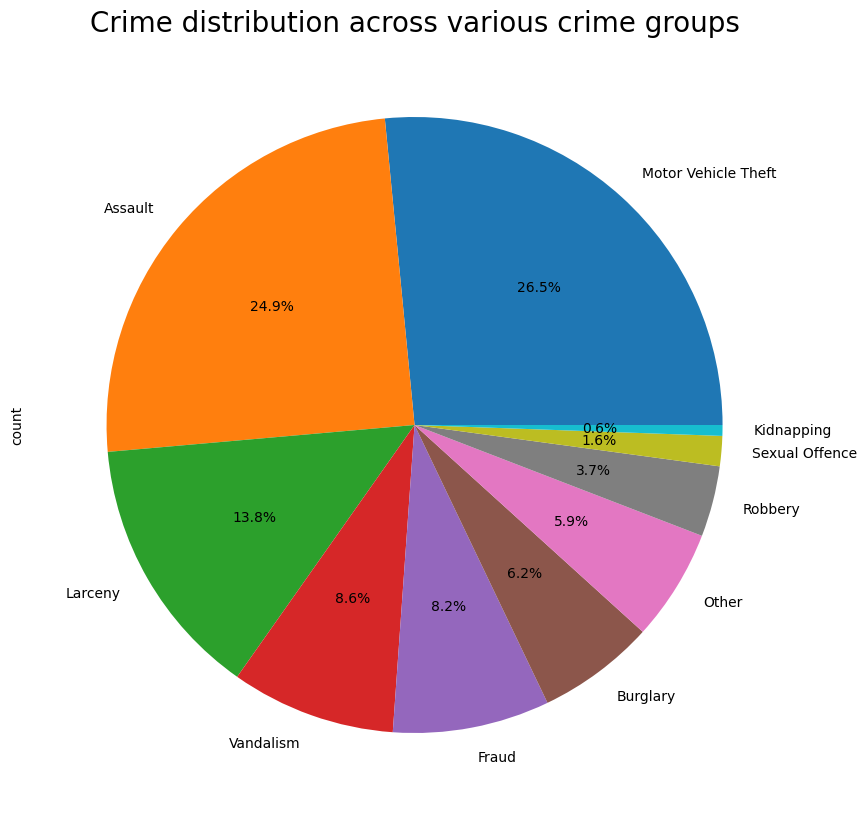

In [48]:
plt.figure(figsize = (10,10))
df['Group'].value_counts()[:10].plot(kind='pie', autopct='%1.1f%%')
plt.title('Crime distribution across various crime groups', fontsize = 20)
plt.show()

**Boxplot for Victim Age across various Crime Groups**

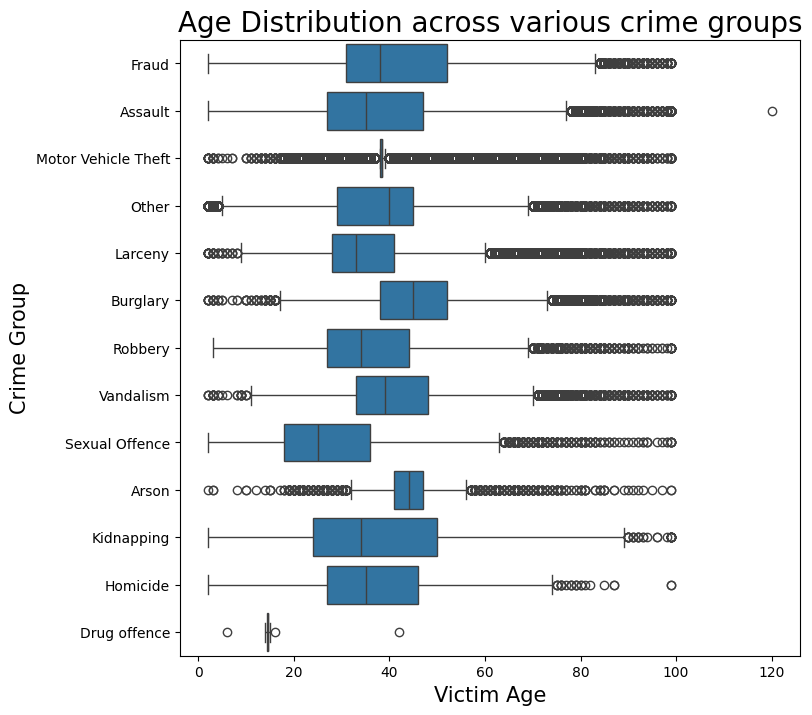

In [49]:
plt.figure(figsize = (8,8))
boxplt = sns.boxplot(data = df, x = 'Vict Age', y = 'Group')
plt.title('Age Distribution across various crime groups', fontsize = 20)
plt.xlabel('Victim Age', fontsize = 15)
plt.ylabel('Crime Group', fontsize = 15)
plt.show()

**Boxplot for Victim Age across various Victim Descents**

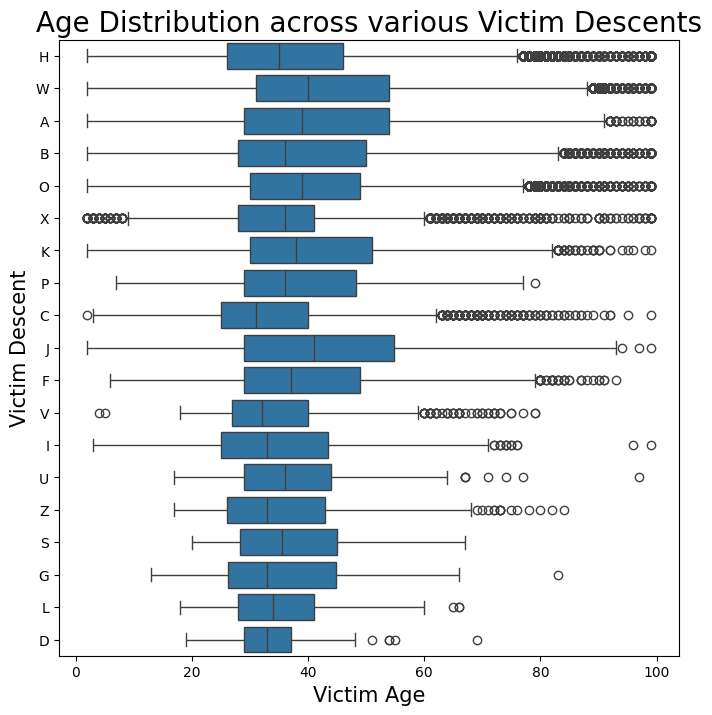

In [50]:
plt.figure(figsize = (8,8))
boxplt = sns.boxplot(data = df, x = 'Vict Age', y = 'Vict Descent')
plt.title('Age Distribution across various Victim Descents', fontsize = 20)
plt.xlabel('Victim Age', fontsize = 15)
plt.ylabel('Victim Descent', fontsize = 15)
plt.show()

**Crime distribution across various locations**

/tmp/ipython-input-54-460704762.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='AREA NAME', order=area_names, palette=light_colors)


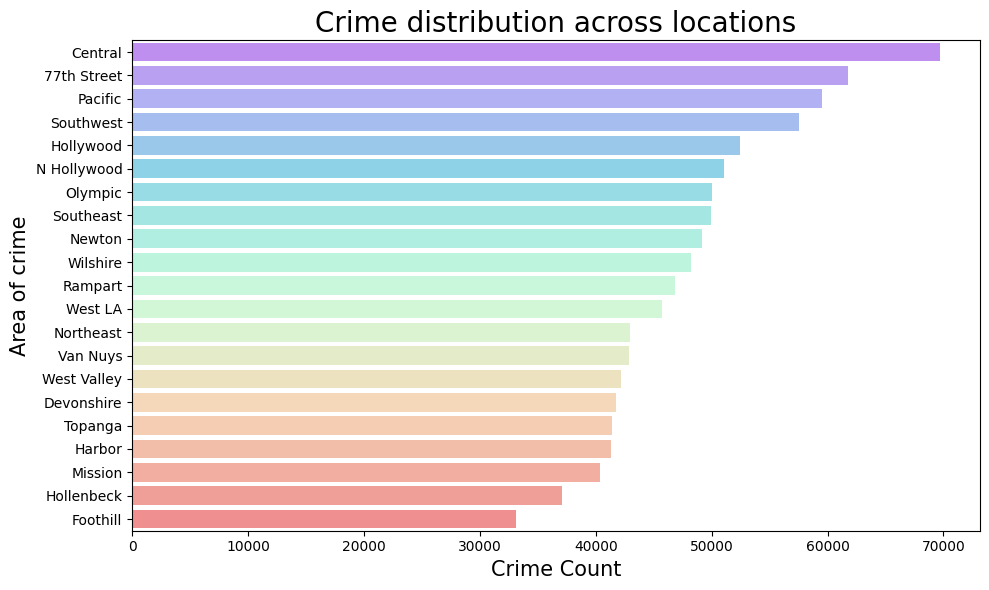

In [54]:
import matplotlib.cm as cm

area_names = df['AREA NAME'].value_counts().index
num_areas = len(area_names)

area_names = df['AREA NAME'].value_counts().index
num_areas = len(area_names)


colors = cm.rainbow(np.linspace(0, 1, num_areas))
light_colors = [((r + 1)/2, (g + 1)/2, (b + 1)/2) for r, g, b, _ in colors]

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='AREA NAME', order=area_names, palette=light_colors)
plt.title('Crime distribution across locations', fontsize=20)
plt.xlabel('Crime Count', fontsize=15)
plt.ylabel('Area of crime', fontsize=15)
plt.tight_layout()
plt.show()



**Crime heatmap**



In [55]:
import folium
from folium.plugins import HeatMap
df_latlong = df[['LAT','LON']].value_counts()
df_latlong = df_latlong.reset_index().rename(columns = {'0' : 'count'})
map = folium.Map(location=[34.073524, -118.354065], zoom_start=10)
HeatMap(df_latlong).add_to(map)
map

Output hidden; open in https://colab.research.google.com to view.

**Crime distribution across Victim's ages**

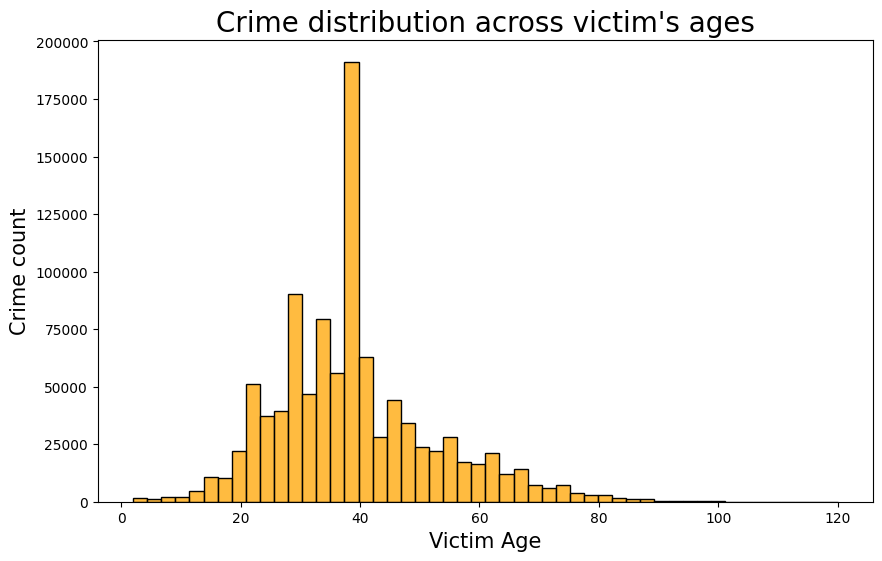

In [56]:
plt.figure(figsize = (10,6))
sns.histplot(df['Vict Age'],
             bins = 50, color = 'orange')
plt.title('Crime distribution across victim\'s ages', fontsize = 20)
plt.xlabel('Victim Age', fontsize = 15)
plt.ylabel('Crime count', fontsize = 15)
plt.show()

**Crime distribution across Victim's Gender**

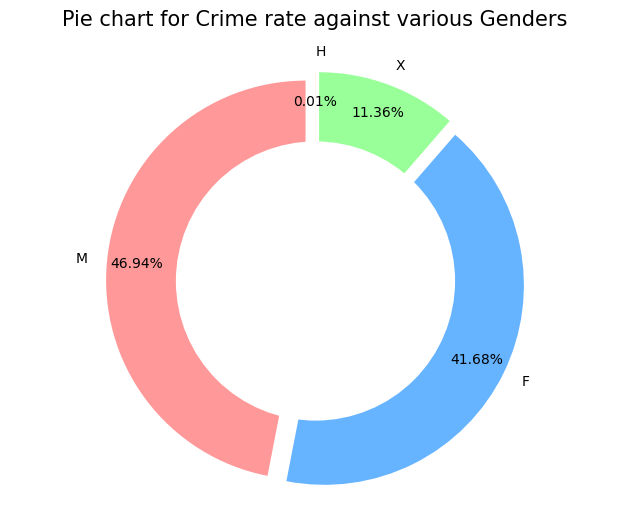

In [57]:
sex = df['Vict Sex'].value_counts().reset_index().rename(columns = {'index':'sex','Vict Sex':'Crime Count'})
labels = sex['Crime Count']
sex['size'] = sex['count']/(sex['count'].sum())*100
sizes = sex['size']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
explode = (0.05,0.05,0.05,0.05)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, colors = colors, labels=labels, autopct='%1.2f%%', startangle=90, pctdistance=0.85, explode = explode)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
ax1.axis('equal')
plt.tight_layout()
plt.title('Pie chart for Crime rate against various Genders', fontsize = 15, y=1.05)
plt.show()

**Crime distribution across various descents**

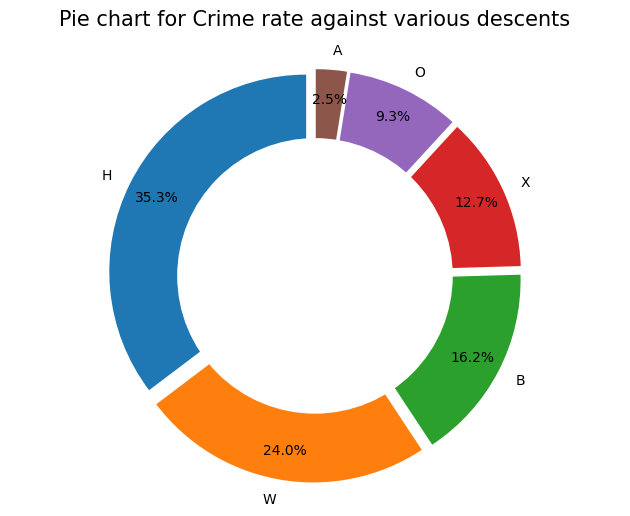

In [58]:
descent = df['Vict Descent'].value_counts()[:6].reset_index().rename(columns = {'index':'Descent','Vict Descent':'Crime Count'})
labels = descent['Crime Count']
descent['size'] = descent['count']/(descent['count'].sum())*100
sizes = descent['size']
explode = (0.05,0.05,0.05,0.05,0.05,0.05)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode = explode)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
ax1.axis('equal')
plt.tight_layout()
plt.title('Pie chart for Crime rate against various descents', fontsize = 15, y=1.05)
plt.show()

**Stripplot to show a correlation between Victim's Age and Gender**

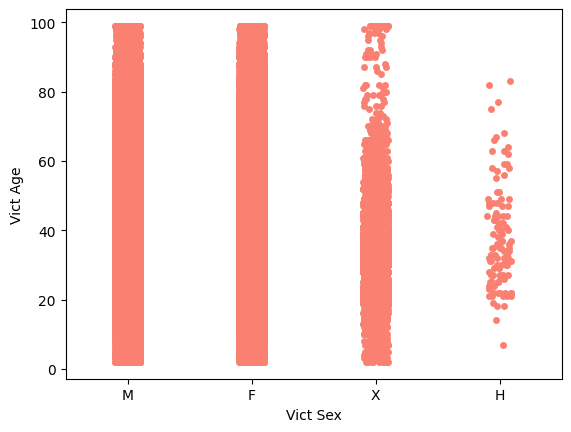

In [59]:
sns.stripplot(data = df.loc[~df['Vict Sex'].isnull()], x = "Vict Sex", y = "Vict Age", color = 'salmon')
plt.show()

**Stripplot to show a correlation between Victim's Age and Descent**

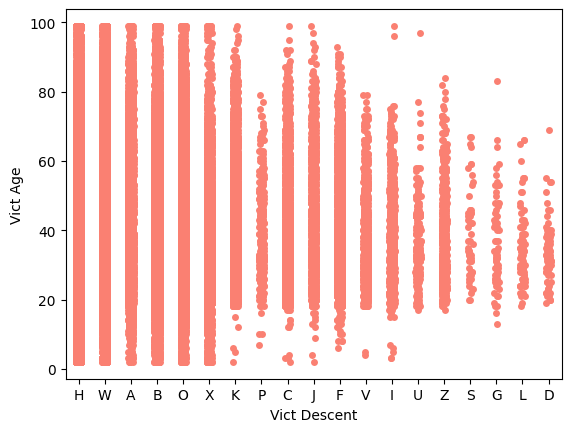

In [60]:
sns.stripplot(data = df.loc[~df['Vict Descent'].isnull()], x = "Vict Descent", y = "Vict Age", color = 'salmon')
plt.show()

### **Timeseries forecasting for next 90 days**

# **ARIMA (AutoRegressive Integrated Moving Average)**

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  

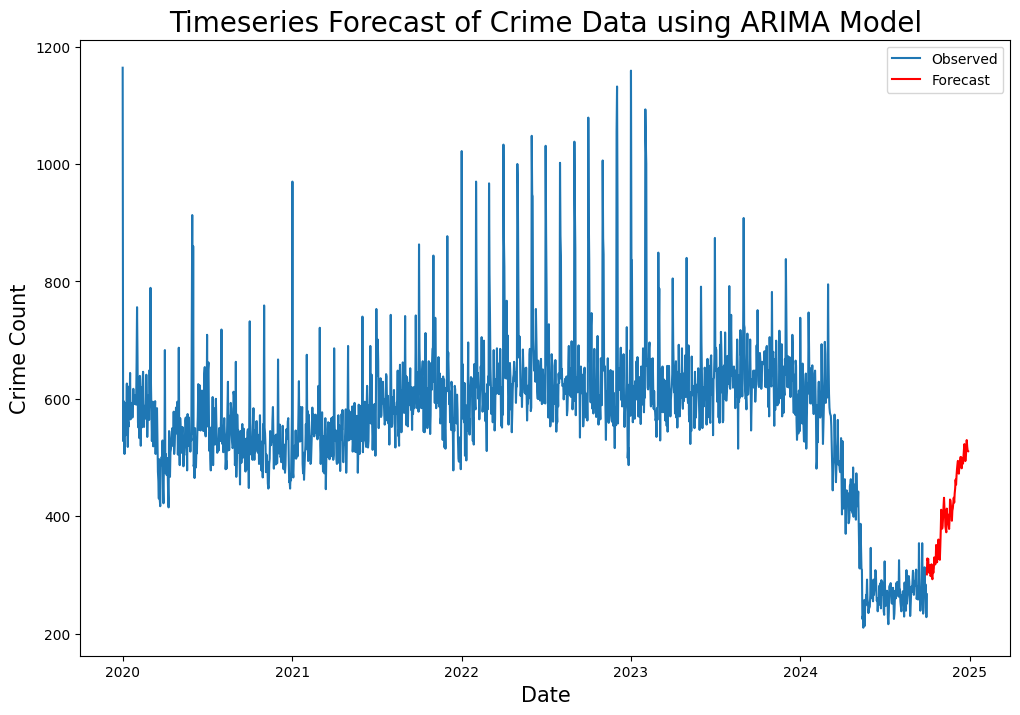

In [62]:
from statsmodels.tsa.arima.model import ARIMA

df_ts = df.loc[df['DATE OCC'] < '2024-10-01']
df_ts = df_ts.groupby('DATE OCC').size().reset_index(name='COUNT')
df_ts = df_ts.set_index('DATE OCC')

model = ARIMA(df_ts, order=(1, 0, 100))
model_fit = model.fit()

forecast_days = 90
forecast = model_fit.forecast(steps=forecast_days)
forecast_dates = pd.date_range(start=df_ts.index[-1], periods=forecast_days)

plt.figure(figsize=(12, 8))
plt.plot(df_ts.index, df_ts['COUNT'], label='Observed')
plt.plot(forecast_dates, forecast, color='red', label='Forecast')
plt.xlabel('Date', fontsize = 15)
plt.ylabel('Crime Count', fontsize = 15)
plt.legend()
plt.title('Timeseries Forecast of Crime Data using ARIMA Model', fontsize = 20)
plt.show()

## **Predictive Analysis**

**Historical Crime Trend (2020–2024):**

1.From 2020 to 2022, the crime count shows frequent fluctuations with periods of both peaks and drops.

2.In 2023, a relatively high and volatile pattern can be observed, indicating unstable crime activity.

3.A sharp decline is seen during mid to late 2024, potentially due to external factors like policy changes, seasonal effects, or reporting gaps.

**Forecasted Trend (Oct–Dec 2024):**

1.The red line represents the ARIMA model’s predicted crime count for the next 90 days.

2.A gradual increase is observed, suggesting that crime activity is expected to rise steadily toward the end of 2024 and into early 2025.

3.This upward trend could be an indicator of seasonal or cyclical patterns in crime rates.

### **Insight:**
The forecast indicates that if current trends continue, the city may face a moderate but consistent rise in daily crime incidents in the coming months. This forecast can assist city planners and law enforcement in preparing ahead with proactive measures.

